In [1]:
import pandas as pd
csv_path = "/titanic.csv"
df = pd.read_csv(csv_path)
print("The first 5 rows: ")
df.head()

The first 5 rows: 


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [7]:
print("DataSet Shape: ")
print(df.shape)

DataSet Shape: 
(891, 15)


In [10]:
print("Column Names: ")
print(df.columns)

Column Names: 
Index(['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare',
       'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town',
       'alive', 'alone'],
      dtype='object')


In [11]:
print("Data types: ")
print(df.dtypes)

Data types: 
survived         int64
pclass           int64
sex             object
age            float64
sibsp            int64
parch            int64
fare           float64
embarked        object
class           object
who             object
adult_male        bool
deck            object
embark_town     object
alive           object
alone             bool
dtype: object


In [12]:
print("Data set Information: ")
print(df.info())

Data set Information: 
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   survived     891 non-null    int64  
 1   pclass       891 non-null    int64  
 2   sex          891 non-null    object 
 3   age          714 non-null    float64
 4   sibsp        891 non-null    int64  
 5   parch        891 non-null    int64  
 6   fare         891 non-null    float64
 7   embarked     889 non-null    object 
 8   class        891 non-null    object 
 9   who          891 non-null    object 
 10  adult_male   891 non-null    bool   
 11  deck         203 non-null    object 
 12  embark_town  889 non-null    object 
 13  alive        891 non-null    object 
 14  alone        891 non-null    bool   
dtypes: bool(2), float64(2), int64(4), object(7)
memory usage: 92.4+ KB
None


In [13]:
df.describe()

,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [15]:
print("Missing Values: ")
df.isnull().sum()

Missing Values: 


,0
survived,0
pclass,0
sex,0
age,177
sibsp,0
parch,0
fare,0
embarked,2
class,0
who,0


In [16]:
df.duplicated()

,0
0,False
1,False
2,False
3,False
4,False
...,...
886,True
887,False
888,False
889,False


In [22]:
print(df["survived"].value_counts())
print(df["survived"].value_counts(normalize=True)*100)

survived
0    549
1    342
Name: count, dtype: int64
survived
0    61.616162
1    38.383838
Name: proportion, dtype: float64


In [18]:
print(df["sex"].value_counts())

sex
male      577
female    314
Name: count, dtype: int64


In [21]:
print(df["alone"].value_counts())

alone
True     537
False    354
Name: count, dtype: int64


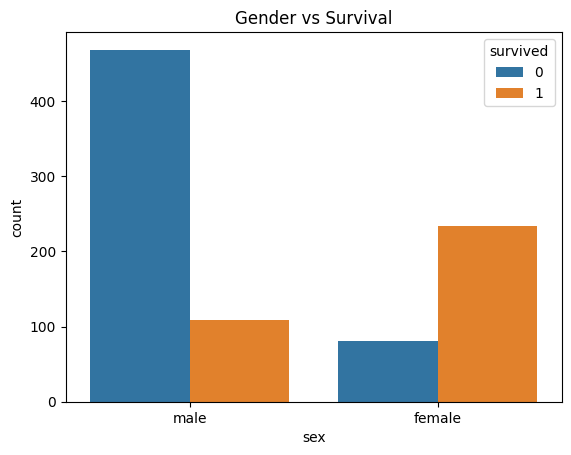

In [23]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='sex', hue='survived', data=df)
plt.title("Gender vs Survival")
plt.show()

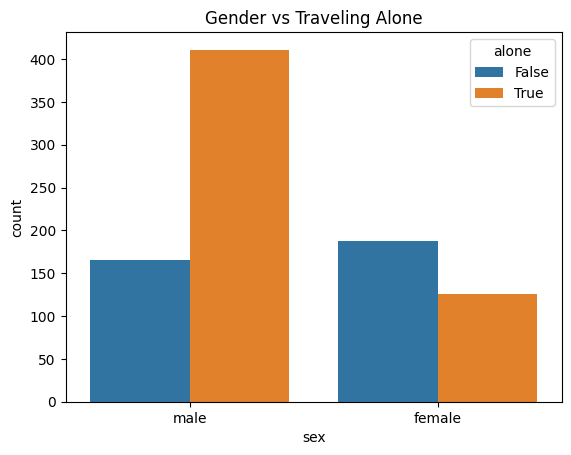

In [26]:
df['alone'] = ((df['sibsp'] + df['parch']) == 0)
sns.countplot(x='sex', hue='alone', data=df)
plt.title("Gender vs Traveling Alone")
plt.show()

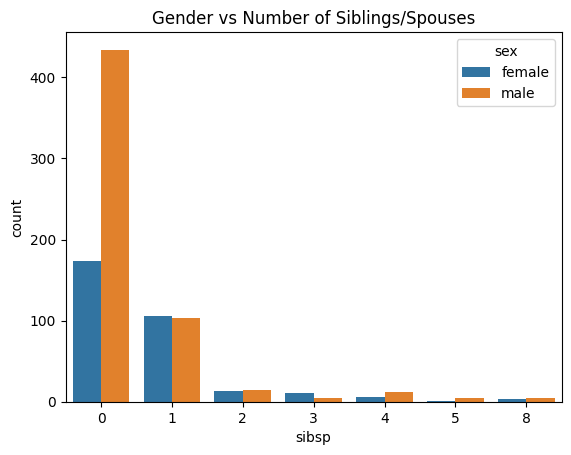

In [27]:
sns.countplot(x='sibsp', hue='sex', data=df)
plt.title("Gender vs Number of Siblings/Spouses")
plt.show()

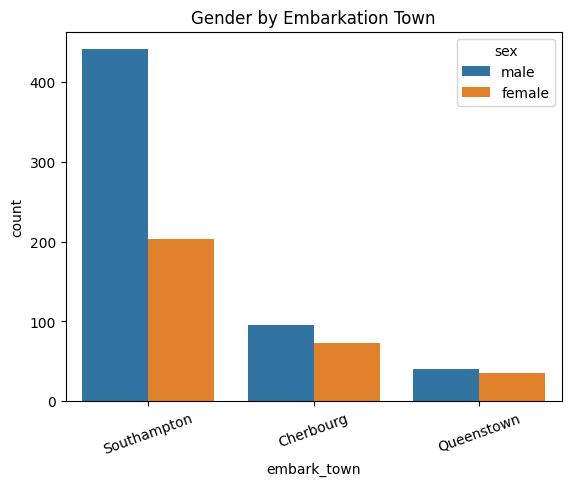

In [28]:
sns.countplot(x='embark_town', hue='sex', data=df)
plt.title("Gender by Embarkation Town")
plt.xticks(rotation=20)
plt.show()

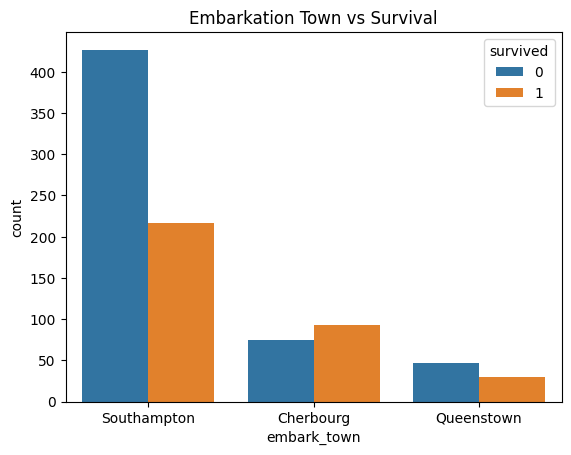

In [29]:
sns.countplot(x='embark_town', hue='survived', data=df)
plt.title("Embarkation Town vs Survival")
plt.show()

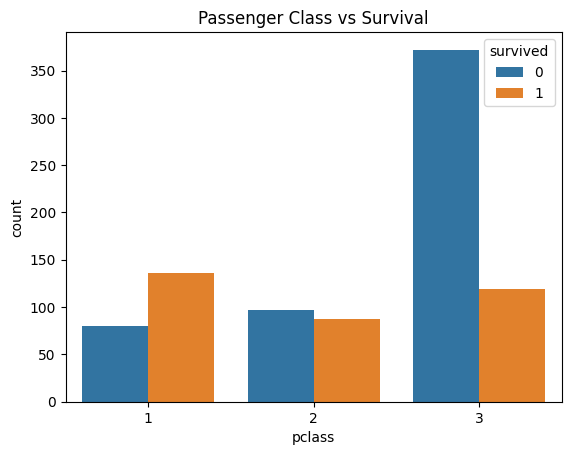

In [30]:
sns.countplot(x='pclass', hue='survived', data=df)
plt.title("Passenger Class vs Survival")
plt.show()

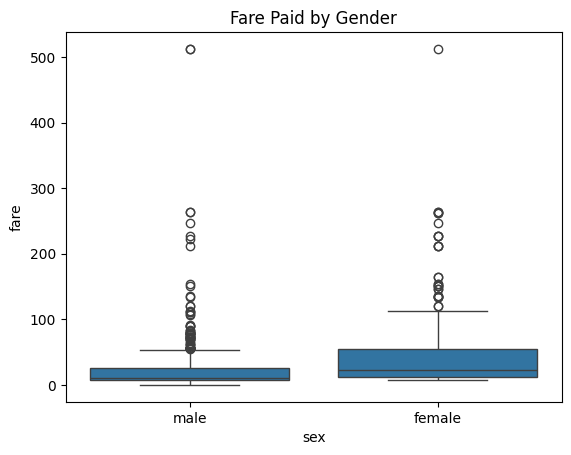

In [31]:
sns.boxplot(x='sex', y='fare', data=df)
plt.title("Fare Paid by Gender")
plt.show()

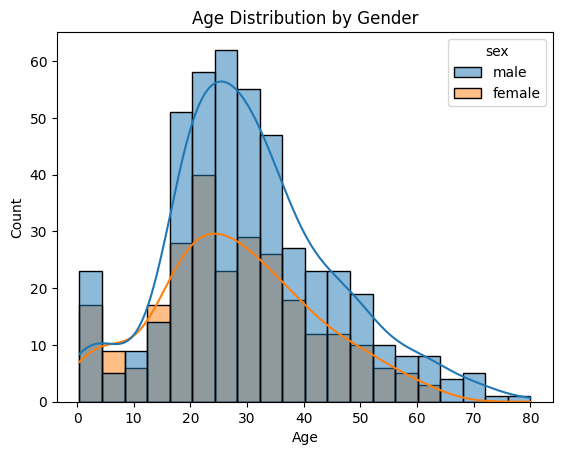

In [38]:
sns.histplot(data=df, x='age', hue='sex', kde=True)
plt.title("Age Distribution by Gender")
plt.show()

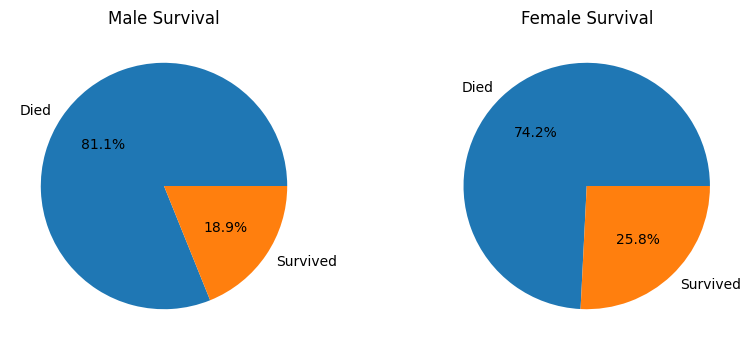

In [35]:
male = df[df['sex'] == 'male']['survived'].value_counts()
female = df[df['sex'] == 'female']['survived'].value_counts()

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.pie(male, labels=['Died','Survived'], autopct='%1.1f%%')
plt.title("Male Survival")

plt.subplot(1,2,2)
plt.pie(female, labels=['Died','Survived'], autopct='%1.1f%%')
plt.title("Female Survival")

plt.show()